In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')



In [67]:
import torch
import pandas as pd

In [9]:
mix = torch.distributions.Categorical(
    probs=torch.tensor([0.5, 0.2, 0.3])
)

# Componentes (vectorizados)
comp = torch.distributions.Normal(
    loc=torch.tensor([0.0, 2.0, -2.0]),
    scale=torch.tensor([1.0, 0.5, 0.2])
)

# Mezcla Gaussiana
gauss_mix = torch.distributions.MixtureSameFamily(
    mixture_distribution=mix,
    component_distribution=comp
)

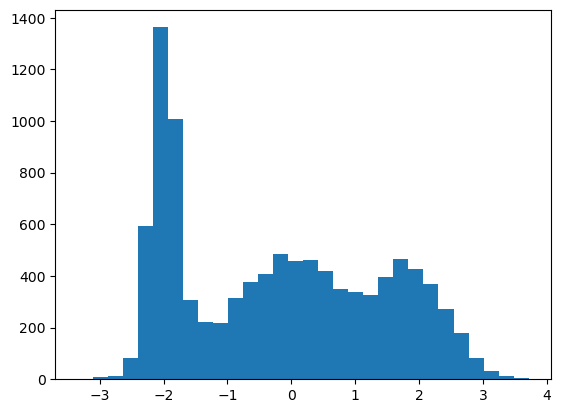

In [20]:
data  = gauss_mix.sample((10000,1))
plt.hist(data.cpu().detach().numpy(), bins=30)
plt.show()

In [85]:
class GaussianMixtureEM:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,) o (N,1)
        n_mix: número de componentes
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N = self.data.shape[0]
        self.n_mix = n_mix

        # atributos que se llenarán al entrenar
        self.theta = None
        self.log_likelihood_history = []

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):
        if seed is not None:
            torch.manual_seed(seed)

        # ----- inicialización -----
        p = torch.ones(self.n_mix) / self.n_mix
        mu = self.data[torch.randint(0, self.N, (self.n_mix,))].squeeze()
        sigma = torch.ones(self.n_mix)

        self.theta = {"p": [p], "mu": [mu], "sigma": [sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for k in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.Normal(mu, sigma)
            log_probs = dist.log_prob(self.data)           # (N,K)
            log_weighted = log_probs + torch.log(p)        # (N,K)

            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)

            p_new = n_k / self.N
            mu_new = (gamma * self.data).sum(dim=0) / n_k
            var_new = (gamma * (self.data - mu_new)**2).sum(dim=0) / n_k
            sigma_new = torch.sqrt(var_new)

            # evitar problemas numéricos
            sigma_new = torch.clamp(sigma_new, min=1e-6)
            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood (con parámetros nuevos) =====
            dist_new = torch.distributions.Normal(mu_new, sigma_new)
            log_probs_new = dist_new.log_prob(self.data)
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {k}, loglik = {ll.item():.6f}")

            # ===== criterio de paro =====
            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            # actualizar parámetros
            p, mu, sigma = p_new, mu_new, sigma_new

            # guardar historial
            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["sigma"].append(sigma)

        return self

    def plot_log_likelihood(self):
        plt.figure()
        plt.plot(self.log_likelihood_history)
        plt.xlabel("Iteración")
        plt.ylabel("Log-verosimilitud")
        plt.title("Convergencia EM")
        plt.grid()
        plt.show()

    def plot_density(self, bins=50, show_components=True):
        """
        Grafica el histograma de los datos junto con la densidad estimada.
        """

        # últimos parámetros estimados
        p = self.theta["p"][-1]
        mu = self.theta["mu"][-1]
        sigma = self.theta["sigma"][-1]

        data = self.data.squeeze()

        # grid para evaluar densidad
        x_min, x_max = data.min().item(), data.max().item()
        x = torch.linspace(x_min, x_max, 500)

        # densidad total
        density = torch.zeros_like(x)

        for j in range(self.n_mix):
            dist = torch.distributions.Normal(mu[j], sigma[j])
            density += p[j] * torch.exp(dist.log_prob(x))

        # ===== plot =====
        plt.figure()

        # histograma
        plt.hist(data.numpy(), bins=bins, density=True, alpha=0.5)

        # mezcla total
        plt.plot(x.numpy(), density.detach().numpy(), linewidth=2, label="Mixture")

        # componentes individuales
        if show_components:
            for j in range(self.n_mix):
                dist = torch.distributions.Normal(mu[j], sigma[j])
                comp_density = p[j] * torch.exp(dist.log_prob(x))
                plt.plot(x.numpy(), comp_density.detach().numpy(), linestyle="--")

        plt.title("Ajuste de Mezcla Gaussiana (EM)")
        plt.xlabel("x")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid()

        plt.show()

In [86]:
model = GaussianMixtureEM(data, n_mix=3)
model(tol=1e-10, seed=42)


Iter 0, loglik = -17099.638672
Iter 1, loglik = -16709.363281
Iter 2, loglik = -16420.359375
Iter 3, loglik = -16239.721680
Iter 4, loglik = -16150.804688
Iter 5, loglik = -16112.449219
Iter 6, loglik = -16096.458008
Iter 7, loglik = -16089.509766
Iter 8, loglik = -16086.137695
Iter 9, loglik = -16084.143555
Iter 10, loglik = -16082.640625
Iter 11, loglik = -16081.245117
Iter 12, loglik = -16079.775391
Iter 13, loglik = -16078.137695
Iter 14, loglik = -16076.251953
Iter 15, loglik = -16074.052734
Iter 16, loglik = -16071.457031
Iter 17, loglik = -16068.372070
Iter 18, loglik = -16064.674805
Iter 19, loglik = -16060.212891
Iter 20, loglik = -16054.799805
Iter 21, loglik = -16048.198242
Iter 22, loglik = -16040.130859
Iter 23, loglik = -16030.279297
Iter 24, loglik = -16018.319336
Iter 25, loglik = -16003.990234
Iter 26, loglik = -15987.203125
Iter 27, loglik = -15968.203125
Iter 28, loglik = -15947.727539
Iter 29, loglik = -15927.011719
Iter 30, loglik = -15907.550781
Iter 31, loglik = 

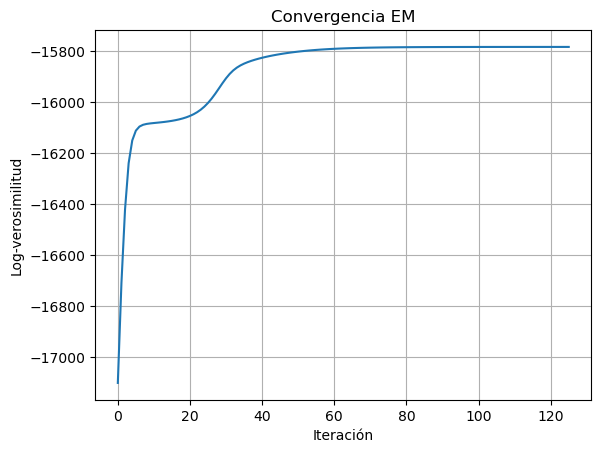

mu: tensor([-0.0101,  1.9704, -2.0012])
sigma: tensor([0.9720, 0.5153, 0.2012])
p: tensor([0.4843, 0.2094, 0.3062])


In [87]:
model.plot_log_likelihood()

# parámetros finales
print("mu:", model.theta["mu"][-1])
print("sigma:", model.theta["sigma"][-1])
print("p:", model.theta["p"][-1])

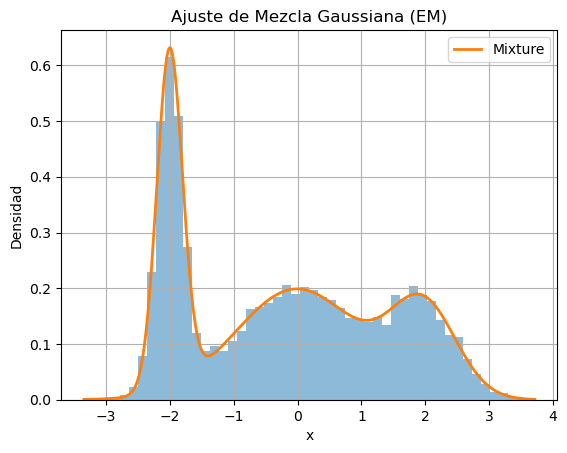

In [90]:
model.plot_density(show_components=False)

In [70]:
data_ins = pd.read_csv("data/claims_q12023.csv",sep=None, engine='python')
data_ins

,cust_age,policy_id,coverage_start_date,cust_region,sum_assured_group,ins_deductible,annual_prem,zip_code,insured_sex,edu_lvl,...,bodily_injuries,witnesses,police_report_avlbl,total_claim_amount,injury_claim,property_claim,vehicle_claim,car_brand,car_model,production_year
0,44,225016,08.09.2007,north,mid,2000,1007.48,342178,F,college,...,0,2,YES,74140,13480,13480,47180,BMW,X5,2022
1,56,316183,02.02.2016,north,mid,500,1080.60,506682,F,phd,...,2,3,NaN,56430,0,6270,50160,Honda,CRV,2021
2,28,174430,04.02.2020,east,mid,2000,1078.03,330854,M,high school,...,0,1,YES,53600,6700,6700,40200,Volkswagen,Jetta,2014
3,53,67527,27.01.2013,north,low,1000,1026.55,502272,F,college,...,0,0,NO,80960,14720,7360,58880,Accura,MDX,2007
4,47,259758,08.04.2015,east,mid,2000,1484.15,515656,F,associate,...,2,3,NaN,64100,12820,6410,44870,Dodge,RAM,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,53,477651,03.03.1998,west,low,2000,1394.54,348690,F,associate,...,2,1,NaN,47430,5270,5270,36890,Toyota,Camry,2007
996,32,265179,20.11.2013,east,high,2000,1255.11,516309,F,high school,...,1,3,NO,61270,5570,11140,44560,Subaru,Legacy,2006
997,29,182883,11.09.2013,west,low,1000,1521.28,510447,M,masters,...,1,2,YES,94560,7880,15760,70920,Jeep,Grand Cherokee,2002
998,56,438442,28.10.2009,west,mid,500,1040.67,516735,M,high school,...,0,2,NO,68040,15120,7560,45360,Subaru,Forrestor,2004


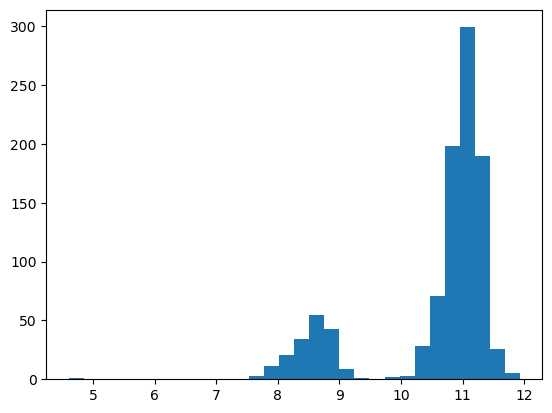

In [102]:
x = torch.tensor(data_ins["total_claim_amount"]).log()
plt.hist(x.cpu(), bins=30)
plt.show()

In [103]:
model_cm = GaussianMixtureEM(x, n_mix=2)
model_cm(tol=1e-10, seed=1997)

Iter 0, loglik = -1377.039551
Iter 1, loglik = -1209.534912
Iter 2, loglik = -858.950562
Iter 3, loglik = -767.977722
Iter 4, loglik = -746.154175
Iter 5, loglik = -736.492920
Iter 6, loglik = -729.177795
Iter 7, loglik = -721.400513
Iter 8, loglik = -711.245911
Iter 9, loglik = -698.174255
Iter 10, loglik = -684.639282
Iter 11, loglik = -675.884521
Iter 12, loglik = -673.523926
Iter 13, loglik = -673.295288
Iter 14, loglik = -673.284424
Iter 15, loglik = -673.284180
Iter 16, loglik = -673.284058
Iter 17, loglik = -673.284058
Convergió


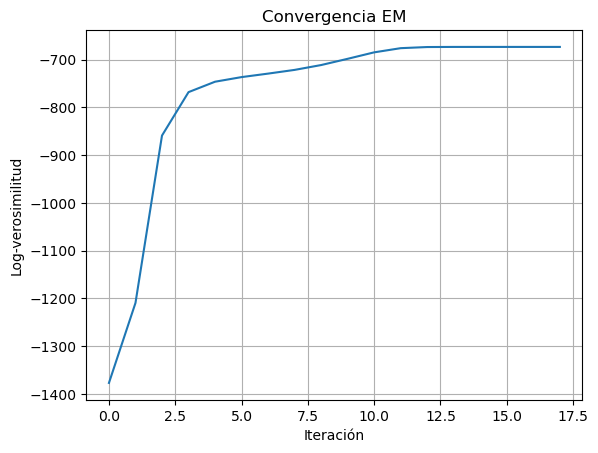

mu: tensor([ 8.5468, 11.0217])
sigma: tensor([0.4681, 0.2681])
p: tensor([0.1804, 0.8196])


In [104]:
model_cm.plot_log_likelihood()
# parámetros finales
print("mu:", model_cm.theta["mu"][-1])
print("sigma:", model_cm.theta["sigma"][-1])
print("p:", model_cm.theta["p"][-1])

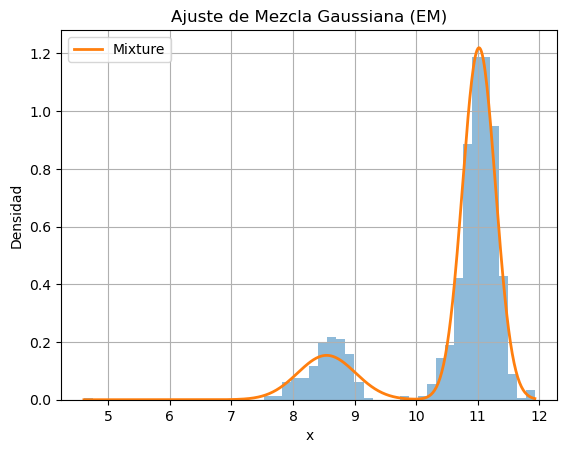

In [105]:
model_cm.plot_density(show_components=False)